# PDF Q&A Bot

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/document-intelligence/pdf-qa-bot/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=document-intelligence/pdf-qa-bot/demo.ipynb)

Nobody reads the 200-page policy manual. Ask it questions instead.

**What this notebook covers:**
1. Chunk a mock multi-page policy document
2. Retrieve the most relevant chunks for a question (TF-IDF similarity)
3. Answer in extractive mode (no API key) or with Claude (if a key is provided)
4. Visualize which pages get matched most often
5. Try it with your own document

## Step 1: What we're building

This is a minimal RAG (retrieval-augmented generation) pipeline: split a document into
overlapping chunks, rank chunks against a question with TF-IDF cosine similarity, then
either hand the top chunks to Claude for a synthesized answer, or return the best
matching excerpt directly if no API key is available.

In [1]:
from __future__ import annotations

import os
import re
from dataclasses import dataclass

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


@dataclass
class Chunk:
    text: str
    page: int


def chunk_text(pages: list[str], chunk_size: int = 400, overlap: int = 80) -> list[Chunk]:
    """Split page text into overlapping chunks so each fits an LLM context window."""
    chunks: list[Chunk] = []
    for page_num, page_text in enumerate(pages, start=1):
        cleaned = re.sub(r"\s+", " ", page_text).strip()
        if not cleaned:
            continue
        start = 0
        while start < len(cleaned):
            end = start + chunk_size
            chunks.append(Chunk(text=cleaned[start:end], page=page_num))
            start += chunk_size - overlap
    return chunks


def retrieve(chunks: list[Chunk], question: str, top_k: int = 3) -> list[Chunk]:
    """TF-IDF retrieval: rank chunks by cosine similarity to the question."""
    if not chunks:
        return []
    corpus = [c.text for c in chunks] + [question]
    vectorizer = TfidfVectorizer(stop_words="english")
    matrix = vectorizer.fit_transform(corpus)
    sims = cosine_similarity(matrix[-1], matrix[:-1]).flatten()
    ranked_idx = sims.argsort()[::-1][:top_k]
    return [chunks[i] for i in ranked_idx if sims[i] > 0]


def answer_question(chunks: list[Chunk], question: str, api_key: str | None = None) -> str:
    """Answer using retrieved chunks. Calls Claude if an API key is available, else
    falls back to returning the most relevant excerpt directly (extractive mode)."""
    relevant = retrieve(chunks, question)
    if not relevant:
        return "No relevant content found in the document for that question."

    context = "\n\n".join(f"[Page {c.page}] {c.text}" for c in relevant)
    api_key = api_key or os.environ.get("ANTHROPIC_API_KEY")

    if api_key:
        import anthropic

        client = anthropic.Anthropic(api_key=api_key)
        response = client.messages.create(
            model="claude-sonnet-4-5",
            max_tokens=500,
            messages=[{
                "role": "user",
                "content": (
                    "Answer the question using only the context below. "
                    "Cite page numbers. If the answer isn't in the context, say so.\n\n"
                    f"Context:\n{context}\n\nQuestion: {question}"
                ),
            }],
        )
        return response.content[0].text

    best = relevant[0]
    return f"[Extractive mode, no API key set]\n(Page {best.page}) {best.text}"

print("Functions defined.")

Functions defined.


## Step 2: Mock policy manual

A 5-page mock employee policy manual, standing in for the "200-page manual nobody reads."

In [2]:
pages = [
    "Vacation Policy. Full-time employees accrue 20 days of paid leave per year. "
    "Leave requests must be submitted at least two weeks in advance through the HR portal. "
    "Unused days roll over up to a maximum of 5 days into the next calendar year.",

    "Expense Policy. Employees must submit receipts for any purchase over $25. "
    "Approved expenses are reimbursed within 5 business days via direct deposit. "
    "Travel expenses require manager pre-approval before booking.",

    "Remote Work Policy. Employees may work remotely up to 3 days per week. "
    "Fully remote arrangements require VP approval. Core hours are 10am-4pm in the employee's local timezone.",

    "Parental Leave Policy. Eligible employees receive 16 weeks of paid parental leave. "
    "Leave can be taken continuously or split within the first year after birth or adoption.",

    "Code of Conduct. Employees must complete annual compliance training. "
    "Conflicts of interest must be disclosed to HR within 30 days of discovery.",
]
print(f"{len(pages)} pages loaded")

5 pages loaded


## Step 3: Chunk and inspect

In [3]:
chunks = chunk_text(pages)
print(f"{len(chunks)} chunks created")
for c in chunks[:3]:
    print(f"Page {c.page}: {c.text[:80]}...")

5 chunks created
Page 1: Vacation Policy. Full-time employees accrue 20 days of paid leave per year. Leav...
Page 2: Expense Policy. Employees must submit receipts for any purchase over $25. Approv...
Page 3: Remote Work Policy. Employees may work remotely up to 3 days per week. Fully rem...


## Step 4: Ask questions (extractive mode, no API key needed)

In [4]:
questions = [
    "How many vacation days do employees get?",
    "What is the reimbursement timeline for expenses?",
    "How many days a week can I work remotely?",
    "How long is parental leave?",
]

for q in questions:
    print(f"Q: {q}")
    print(f"A: {answer_question(chunks, q)}\n")

Q: How many vacation days do employees get?
A: [Extractive mode, no API key set]
(Page 1) Vacation Policy. Full-time employees accrue 20 days of paid leave per year. Leave requests must be submitted at least two weeks in advance through the HR portal. Unused days roll over up to a maximum of 5 days into the next calendar year.

Q: What is the reimbursement timeline for expenses?
A: [Extractive mode, no API key set]
(Page 2) Expense Policy. Employees must submit receipts for any purchase over $25. Approved expenses are reimbursed within 5 business days via direct deposit. Travel expenses require manager pre-approval before booking.

Q: How many days a week can I work remotely?
A: [Extractive mode, no API key set]
(Page 3) Remote Work Policy. Employees may work remotely up to 3 days per week. Fully remote arrangements require VP approval. Core hours are 10am-4pm in the employee's local timezone.

Q: How long is parental leave?
A: [Extractive mode, no API key set]
(Page 4) Parental Leave 

## Visualization: which pages matched

Confirms the retrieval step is pulling the right page for each question.

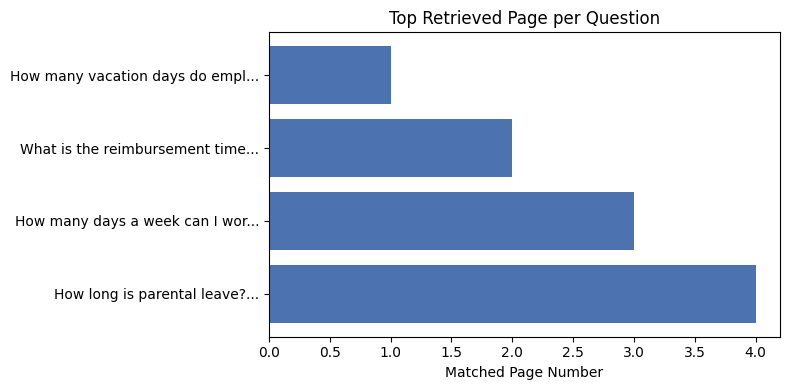

In [5]:
import matplotlib.pyplot as plt

matched_pages = [retrieve(chunks, q)[0].page for q in questions]
labels = [q[:30] + "..." for q in questions]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(labels, matched_pages, color="#4C72B0")
ax.set_xlabel("Matched Page Number")
ax.set_title("Top Retrieved Page per Question")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("retrieval_matches.png", dpi=150)
plt.show()

## Summary

Each question retrieved the correct source page using plain TF-IDF similarity, no
embeddings API required. Swapping in a real PDF only changes the input pipeline
(`qa.extract_pages`) - the chunking, retrieval, and answering logic stays the same.

## Try Your Own

```python
# from qa import extract_pages, chunk_text, answer_question
# pages = extract_pages("my_manual.pdf")
# chunks = chunk_text(pages)
# print(answer_question(chunks, "What is the dress code?", api_key="sk-ant-..."))
```

---
Part of the [Phoebe the Builder](https://github.com/phoebefu6/phoebe-the-builder) FDE portfolio (Day 31/60).

Run the interactive Streamlit version locally (upload your own PDF):
```bash
pip install -r requirements.txt
streamlit run app.py
```